In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FastDataset(Dataset):
    def __init__(self, path):
        self.data = torch.load(path)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        d = self.data[idx]
        return d["seq"], d["rg"], d["dist"]

dataset = FastDataset("/content/drive/MyDrive/processed_dataset_6x6.pt")

loader = DataLoader(dataset, batch_size=8, shuffle=True)

print("Dataset size:", len(dataset))

Mounted at /content/drive
Dataset size: 800


In [ ]:
def compute_pairwise_6x6(dist, seq):
    """
    dist: (B, L, L, bins)
    seq:  (B, L) values in [0..5]

    returns:
        (B, 6, 6, bins)
    """
    B, L, _, bins = dist.shape

    out = torch.zeros(B, 6, 6, bins, device=dist.device)
    counts = torch.zeros(B, 6, 6, 1, device=dist.device)

    for a in range(6):
        for b in range(6):
            mask_i = (seq == a).unsqueeze(2)   # (B, L, 1)
            mask_j = (seq == b).unsqueeze(1)   # (B, 1, L)

            mask = mask_i & mask_j             # (B, L, L)

            mask = mask.unsqueeze(-1)          # (B, L, L, 1)

            pair_sum = (dist * mask).sum(dim=(1,2))   # (B, bins)
            pair_count = mask.sum(dim=(1,2))          # (B, 1)

            out[:, a, b] = pair_sum
            counts[:, a, b] = pair_count + 1e-8

    out = out / counts
    return out

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RgModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.d_model = 96  # increased

        self.embedding = nn.Embedding(6, self.d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=4,
            dim_feedforward=192,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.dist_head = nn.Sequential(
            nn.Linear(2*self.d_model, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

        self.rg_attention = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        h = self.embedding(x)
        h = self.transformer(h)

        B, L, D = h.shape

        hi = h.unsqueeze(2).expand(B, L, L, D)
        hj = h.unsqueeze(1).expand(B, L, L, D)
        pair = torch.cat([hi, hj], dim=-1)

        d_ij = F.softplus(self.dist_head(pair)).squeeze(-1)

        # symmetry
        d_ij = 0.5 * (d_ij + d_ij.transpose(1,2))

        # mask
        mask = 1 - torch.eye(L, device=d_ij.device)
        mask = mask.unsqueeze(0)

        weights = self.rg_attention(d_ij.unsqueeze(-1)).squeeze(-1)
        weights = weights.masked_fill(mask == 0, -1e9)

        weights = torch.softmax(weights.view(B, -1), dim=-1).view(B, L, L)

        rg2 = ((d_ij**2) * weights).sum(dim=(1,2))
        pred_rg = torch.sqrt(rg2 + 1e-8)

        return pred_rg

In [ ]:
import torch.nn.functional as F
import torch

model = RgModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

def corr_loss(pred, target):
    pred = pred - pred.mean()
    target = target - target.mean()
    return - (pred * target).mean() / (pred.std() * target.std() + 1e-8)

epochs = 20

for epoch in range(epochs):
    total_loss = 0
    all_preds = []

    model.train()

    for x, y_rg, _ in loader:
        x = x.to(device)
        y_rg = y_rg.to(device)

        pred_rg = model(x)

        loss_mse = F.mse_loss(pred_rg, y_rg)
        loss_corr = corr_loss(pred_rg, y_rg)

        loss = loss_mse + 0.3 * loss_corr

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_preds.append(pred_rg.detach().cpu())

    # ----------------------------
    # EPOCH METRICS
    # ----------------------------
    all_preds = torch.cat(all_preds)

    print(f"Epoch {epoch+1}")
    print(f"Loss: {total_loss / len(loader):.4f}")
    print(f"Rg std: {all_preds.std().item():.3f}")
    print("-"*30)

Epoch 1
Loss: 468.5831
Rg std: 9.705
------------------------------
Epoch 2
Loss: 42.3091
Rg std: 0.579
------------------------------
Epoch 3
Loss: 39.9238
Rg std: 1.292
------------------------------
Epoch 4
Loss: 26.4144
Rg std: 3.013
------------------------------
Epoch 5
Loss: 18.9343
Rg std: 4.488
------------------------------
Epoch 6
Loss: 17.6963
Rg std: 4.772
------------------------------
Epoch 7
Loss: 16.9088
Rg std: 4.969
------------------------------
Epoch 8
Loss: 16.7642
Rg std: 5.053
------------------------------
Epoch 9
Loss: 14.8502
Rg std: 4.921
------------------------------
Epoch 10
Loss: 13.7651
Rg std: 5.137
------------------------------
Epoch 11
Loss: 14.5977
Rg std: 5.209
------------------------------
Epoch 12
Loss: 13.5577
Rg std: 5.212
------------------------------
Epoch 13
Loss: 13.4508
Rg std: 5.259
------------------------------
Epoch 14
Loss: 13.3771
Rg std: 5.358
------------------------------
Epoch 15
Loss: 13.2312
Rg std: 5.266
-------------------

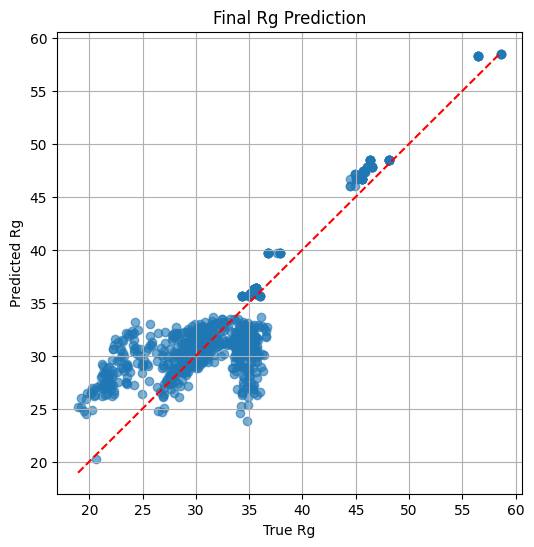

MAE: 2.663
RMSE: 3.545
Correlation: 0.841
Pred std: 5.871


In [ ]:
import torch
import matplotlib.pyplot as plt

model.eval()

all_true = []
all_pred = []

with torch.no_grad():
    for x, y_rg, _ in loader:
        x = x.to(device)
        y_rg = y_rg.to(device)

        pred_rg = model(x)  # ✅ FIXED

        all_true.append(y_rg.cpu())
        all_pred.append(pred_rg.cpu())

all_true = torch.cat(all_true)
all_pred = torch.cat(all_pred)

# ----------------------------
# PLOT
# ----------------------------
plt.figure(figsize=(6,6))
plt.scatter(all_true, all_pred, alpha=0.6)

minv = min(all_true.min(), all_pred.min())
maxv = max(all_true.max(), all_pred.max())

plt.plot([minv, maxv], [minv, maxv], 'r--')

plt.xlabel("True Rg")
plt.ylabel("Predicted Rg")
plt.title("Final Rg Prediction")

plt.grid()
plt.show()

# ----------------------------
# METRICS
# ----------------------------
mae = (all_true - all_pred).abs().mean().item()
rmse = torch.sqrt(((all_true - all_pred)**2).mean()).item()

corr = torch.corrcoef(torch.stack([all_true, all_pred]))[0,1].item()

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"Correlation: {corr:.3f}")
print(f"Pred std: {all_pred.std().item():.3f}")

In [ ]:
# save model
torch.save(model.state_dict(), "rg_model.pt")